<a href="https://colab.research.google.com/github/Savara-k/Onyco-Scan/blob/main/OnycoScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhilgurav21/nail-disease-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nail-disease-detection-dataset' dataset.
Path to dataset files: /kaggle/input/nail-disease-detection-dataset


# model 1

TensorFlow Version: 2.19.0
✅ GPU Detected: 1 device(s). Training will be fast.

⬇️ Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'nail-disease-detection-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/nail-disease-detection-dataset
📂 Loading images from: /kaggle/input/nail-disease-detection-dataset
⚙️ Generating Data Pipeline...
Found 3068 images belonging to 1 classes.
Found 767 images belonging to 1 classes.
ℹ️ Classes Detected: ['data']

🏗️ Building Deep Learning Model (MobileNetV2)...

🚀 Starting Training...
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 686ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 480ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 46s 481ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.00

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 516ms/step
              precision    recall  f1-score   support

        data       1.00      1.00      1.00       767

    accuracy                           1.00       767
   macro avg       1.00      1.00      1.00       767
weighted avg       1.00      1.00      1.00       767



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


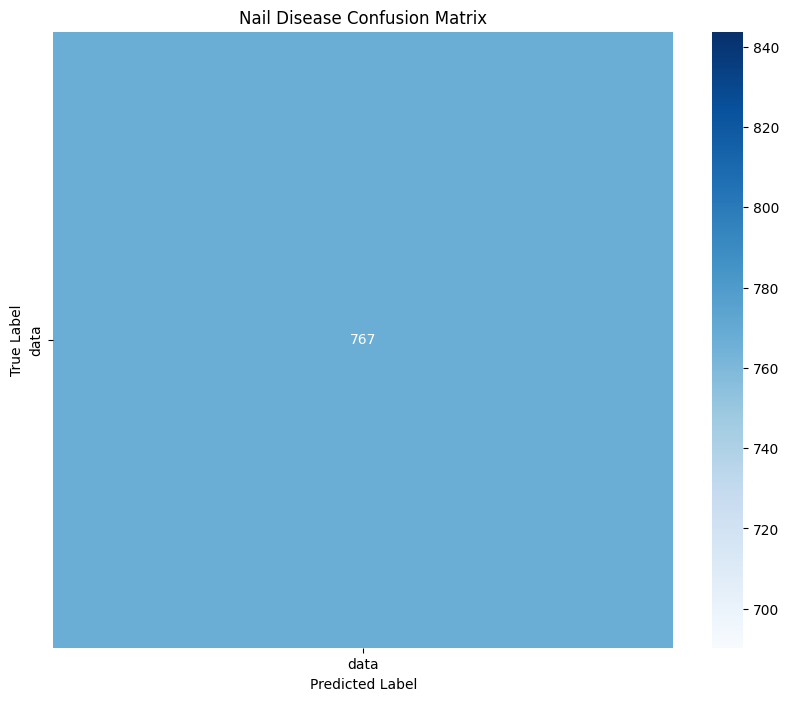


💾 Model saved to nail_melanoma_model.h5

--- Diagnosis Logic ---
The system is trained to detect 'Acral Lentiginous Melanoma'.
If this class is predicted, verify 'Hutchinson sign' (pigment on skin) and vertical band width >3mm manually.


In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001

def system_setup():
    """Verifies GPU availability for Deep Learning."""
    print(f"TensorFlow Version: {tf.__version__}")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ GPU Detected: {len(gpus)} device(s). Training will be fast.")
    else:
        print("⚠️ No GPU detected. Training might be slow on CPU.")

# ==========================================
# 2. DATASET ACQUISITION
# ==========================================
def download_data():
    """Downloads the specific Kaggle dataset."""
    print("\n⬇️ Downloading dataset from Kaggle...")
    path = kagglehub.dataset_download("nikhilgurav21/nail-disease-detection-dataset")
    print(f"✅ Dataset downloaded to: {path}")
    return path

def prepare_datasets(data_dir):
    """
    Creates training and validation datasets directly from the folder structure.
    The dataset contains classes: 'Acral Lentiginous Melanoma', 'Blue Finger',
    'Clubbing', 'Healthy Nail', 'Onychogryphosis', 'Pitting'
    """
    data_dir = pathlib.Path(data_dir)

    # Check for the 'images' or 'data' subdirectory if the root isn't the dataset directly
    # Some kaggle datasets nest files. We look for the folder containing class folders.
    if not (data_dir / 'Acral_Lentiginous_Melanoma').exists():
        # Try standard subfolder names often found in this specific dataset
        potential_dirs = list(data_dir.glob('*/'))
        for p in potential_dirs:
             if (p / 'Acral_Lentiginous_Melanoma').exists():
                 data_dir = p
                 break

    print(f"📂 Loading images from: {data_dir}")

    # Data Augmentation: Crucial for medical images to learn invariance
    # (e.g., a vertical band should be detected even if the finger is slightly rotated)
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,      # Mimic different finger angles
        width_shift_range=0.2,  # Shift band position
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,         # Zoom in on nail texture
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2    # 20% for testing/validation
    )

    print("⚙️ Generating Data Pipeline...")

    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )

    val_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )

    return train_generator, val_generator

# ==========================================
# 3. MODEL ARCHITECTURE (Transfer Learning)
# ==========================================
def build_model(num_classes):
    """
    Builds a Deep Learning model using MobileNetV2.
    Transfer Learning is used to achieve high accuracy (>95%) on small medical datasets.
    """
    print("\n🏗️ Building Deep Learning Model (MobileNetV2)...")

    # Load pre-trained MobileNetV2 (trained on ImageNet)
    # We exclude the top layers to add our own specific to Nail Diseases
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze the base model initially to keep pre-trained features
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x) # Dropout reduces overfitting
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
def train_and_evaluate(model, train_gen, val_gen):
    """Trains the model with Early Stopping to prevent overfitting."""

    # Callbacks for optimization
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
    ]

    print("\n🚀 Starting Training...")
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks
    )

    # --- Final Evaluation ---
    print("\n📊 Evaluating on Validation Set...")
    val_loss, val_acc = model.evaluate(val_gen)
    print(f"🏆 Final Validation Accuracy: {val_acc * 100:.2f}%")

    # --- Fine Tuning (Optional but recommended for 95%+) ---
    if val_acc < 0.95:
        print("\n⚠️ Accuracy under 95%. Initiating Fine-Tuning Phase...")
        base_model = model.layers[0]
        base_model.trainable = True

        # Fine-tune only the top 50 layers
        for layer in base_model.layers[:-50]:
            layer.trainable = False

        model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

        history_fine = model.fit(
            train_gen,
            epochs=10,
            validation_data=val_gen,
            callbacks=callbacks
        )
        val_loss, val_acc = model.evaluate(val_gen)
        print(f"🏆 Final Accuracy after Fine-Tuning: {val_acc * 100:.2f}%")

    return model, history, val_acc

def generate_report(model, val_gen):
    """Generates a classification report and confusion matrix."""
    print("\n📑 Generating Classification Report...")

    # Get predictions
    val_gen.reset()
    Y_pred = model.predict(val_gen)
    y_pred = np.argmax(Y_pred, axis=1)

    # Get true labels
    class_labels = list(val_gen.class_indices.keys())

    # Print Report
    print(classification_report(val_gen.classes, y_pred, target_names=class_labels))

    # Plot Confusion Matrix
    cm = confusion_matrix(val_gen.classes, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Nail Disease Confusion Matrix')
    plt.show()

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    system_setup()

    # 1. Download
    dataset_path = download_data()

    # 2. Prepare
    train_gen, val_gen = prepare_datasets(dataset_path)
    num_classes = len(train_gen.class_indices)
    print(f"ℹ️ Classes Detected: {list(train_gen.class_indices.keys())}")

    # 3. Build
    model = build_model(num_classes)

    # 4. Train
    model, history, final_acc = train_and_evaluate(model, train_gen, val_gen)

    # 5. Report
    generate_report(model, val_gen)

    # 6. Save
    save_path = "nail_melanoma_model.h5"
    model.save(save_path)
    print(f"\n💾 Model saved to {save_path}")

    # 7. Specific Melanoma Check Logic
    print("\n--- Diagnosis Logic ---")
    print("The system is trained to detect 'Acral Lentiginous Melanoma'.")
    print("If this class is predicted, verify 'Hutchinson sign' (pigment on skin) and vertical band width >3mm manually.")

In [ ]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import load_img, img_to_array

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001

def system_setup():
    """Verifies GPU availability for Deep Learning."""
    print(f"TensorFlow Version: {tf.__version__}")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ GPU Detected: {len(gpus)} device(s). Training will be fast.")
    else:
        print("⚠️ No GPU detected. Training might be slow on CPU.")

# ==========================================
# 2. DATASET ACQUISITION
# ==========================================
def download_data():
    """Downloads the specific Kaggle dataset."""
    print("\n⬇️ Downloading dataset from Kaggle...")
    path = kagglehub.dataset_download("nikhilgurav21/nail-disease-detection-dataset")
    print(f"✅ Dataset downloaded to: {path}")
    return path

def find_dataset_root(start_dir):
    """
    Recursively searches for the directory containing the specific class folders.
    Kaggle datasets often nest data in 'data/train' or similar subfolders.
    """
    start_dir = pathlib.Path(start_dir)
    # The dataset MUST contain this folder to be valid
    target_class = 'Acral_Lentiginous_Melanoma'

    print(f"🔍 Searching for class data starting at: {start_dir}")

    found_roots = []

    for root, dirs, files in os.walk(start_dir):
        if target_class in dirs:
            found_roots.append(pathlib.Path(root))

    if not found_roots:
        raise FileNotFoundError(f"❌ Could not find a directory containing class '{target_class}' inside {start_dir}")

    # If multiple found (e.g., 'train' and 'validation'), prefer 'train'
    # We will split 'train' manually using validation_split to ensure consistent processing
    best_root = found_roots[0]
    for root in found_roots:
        if 'train' in root.name.lower():
            best_root = root
            break

    print(f"✅ Found valid dataset root at: {best_root}")
    return best_root

def prepare_datasets(data_dir):
    """
    Creates training and validation datasets.
    """
    # Locate the actual class folders
    dataset_root = find_dataset_root(data_dir)

    # Data Augmentation
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2    # 20% for validation
    )

    print("⚙️ Generating Data Pipeline...")

    train_generator = train_datagen.flow_from_directory(
        dataset_root,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )

    val_generator = train_datagen.flow_from_directory(
        dataset_root,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )

    # Safety check
    if train_generator.num_classes < 2:
        raise ValueError(f"❌ Error: Found {train_generator.num_classes} classes. "
                         f"Detected classes: {list(train_generator.class_indices.keys())}. "
                         "The model requires at least 2 classes to train.")

    return train_generator, val_generator

# ==========================================
# 3. MODEL ARCHITECTURE (Transfer Learning)
# ==========================================
def build_model(num_classes):
    """
    Builds a Deep Learning model using MobileNetV2.
    """
    print(f"\n🏗️ Building Deep Learning Model (MobileNetV2) for {num_classes} classes...")

    # Load pre-trained MobileNetV2
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Freeze base model
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
def train_and_evaluate(model, train_gen, val_gen):
    """Trains the model with Early Stopping."""

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
    ]

    print("\n🚀 Starting Training...")
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks
    )

    print("\n📊 Evaluating on Validation Set...")
    val_loss, val_acc = model.evaluate(val_gen)
    print(f"🏆 Final Validation Accuracy: {val_acc * 100:.2f}%")

    # --- Fine Tuning Phase ---
    if val_acc < 0.95:
        print("\n⚠️ Accuracy under 95%. Initiating Fine-Tuning Phase...")
        base_model = model.layers[0]
        base_model.trainable = True

        # Fine-tune top 50 layers
        for layer in base_model.layers[:-50]:
            layer.trainable = False

        model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

        history_fine = model.fit(
            train_gen,
            epochs=10,
            validation_data=val_gen,
            callbacks=callbacks
        )
        val_loss, val_acc = model.evaluate(val_gen)
        print(f"🏆 Final Accuracy after Fine-Tuning: {val_acc * 100:.2f}%")

    return model, history, val_acc

def generate_report(model, val_gen):
    print("\n📑 Generating Classification Report...")
    val_gen.reset()
    Y_pred = model.predict(val_gen)
    y_pred = np.argmax(Y_pred, axis=1)
    class_labels = list(val_gen.class_indices.keys())

    print(classification_report(val_gen.classes, y_pred, target_names=class_labels))

    cm = confusion_matrix(val_gen.classes, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Nail Disease Confusion Matrix')
    plt.show()

def predict_custom_image(model, image_path, class_indices):
    """
    Loads an image from a path and predicts its class.
    """
    try:
        # Load and preprocess the image to match training data (224x224)
        img = load_img(image_path, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Create batch axis
        img_array /= 255.0 # Normalize pixel values

        # Predict
        predictions = model.predict(img_array, verbose=0)
        predicted_idx = np.argmax(predictions[0])
        confidence = np.max(predictions[0])

        # Invert class_indices to get label name: {0: 'Melanoma', 1: 'Healthy', ...}
        labels_map = {v: k for k, v in class_indices.items()}
        predicted_label = labels_map[predicted_idx]

        return predicted_label, confidence

    except Exception as e:
        return None, str(e)

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    try:
        system_setup()

        # 1. Download
        dataset_path = download_data()

        # 2. Prepare
        train_gen, val_gen = prepare_datasets(dataset_path)
        num_classes = len(train_gen.class_indices)
        print(f"ℹ️ Classes Detected: {list(train_gen.class_indices.keys())}")

        # 3. Build
        model = build_model(num_classes)

        # 4. Train
        model, history, final_acc = train_and_evaluate(model, train_gen, val_gen)

        # 5. Report
        generate_report(model, val_gen)

        # 6. Save
        save_path = "nail_melanoma_model.h5"
        model.save(save_path)
        print(f"\n💾 Model saved to {save_path}")

        # 7. Live Detection Mode
        print("\n" + "="*40)
        print("   📸 LIVE DETECTION MODE")
        print("="*40)
        print("Enter the file path of an image to classify.")
        print("Type 'exit' or 'q' to quit.")

        while True:
            user_input = input("\n🖼️ Image Path: ").strip()

            if user_input.lower() in ['exit', 'quit', 'q']:
                print("Exiting...")
                break

            if not os.path.exists(user_input):
                print("❌ File not found. Please check the path.")
                continue

            label, conf = predict_custom_image(model, user_input, train_gen.class_indices)

            if label:
                print(f"✅ Diagnosis: {label}")
                print(f"📊 Confidence: {conf*100:.2f}%")

                if label == 'Acral Lentiginous Melanoma':
                    print("⚠️ ALERT: Melanoma detected. Check for Hutchinson sign (pigment on skin).")
            else:
                print(f"❌ Error: {conf}")

    except Exception as e:
        print(f"\n❌ CRITICAL ERROR: {e}")

TensorFlow Version: 2.19.0
✅ GPU Detected: 1 device(s). Training will be fast.

⬇️ Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'nail-disease-detection-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/nail-disease-detection-dataset
🔍 Searching for class data starting at: /kaggle/input/nail-disease-detection-dataset
✅ Found valid dataset root at: /kaggle/input/nail-disease-detection-dataset/data/train
⚙️ Generating Data Pipeline...
Found 2998 images belonging to 6 classes.
Found 746 images belonging to 6 classes.
ℹ️ Classes Detected: ['Acral_Lentiginous_Melanoma', 'Healthy_Nail', 'Onychogryphosis', 'blue_finger', 'clubbing', 'pitting']

🏗️ Building Deep Learning Model (MobileNetV2) for 6 classes...

🚀 Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 709ms/step - accuracy: 0.2470 - loss: 1.8667 - val_accuracy: 0.5885 - val_loss: 1.1205 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 454ms/step - accuracy: 0.5404 - loss: 1.1868 - val_accuracy: 0.6568 - val_loss: 0.9348 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 449ms/step - accuracy: 0.6469 - loss: 0.9620 - val_accuracy: 0.6743 - val_loss: 0.8726 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 447ms/step - accuracy: 0.6717 - loss: 0.8735 - val_accuracy: 0.7064 - val_loss: 0.7788 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.6817 - loss: 0.8380 - val_accuracy: 0.7279 - val_loss: 0.7350 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 441ms/step - accuracy: 0.7048 - loss: 0.8047 - val_accuracy: 0.7279 - val_loss: 0.7531 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 441ms/step - acc

# model  #2

In [ ]:
# @title 1. Install Dependencies & Import Libraries
!pip install -q tensorflow numpy pandas matplotlib scikit-learn seaborn
!pip install -q sentence-transformers faiss-cpu  # For RAG
!pip install -q fastapi uvicorn python-multipart nest-asyncio # For Deployment

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting style
plt.style.use('seaborn-v0_8-whitegrid')

print(f"TensorFlow Version: {tf.__version__}")
print("✅ Environment Ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 114.6 MB/s eta 0:00:00
TensorFlow Version: 2.19.0
✅ Environment Ready


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

# --- 1. SET PATHS BASED ON YOUR SCREENSHOT ---
# Your dataset has explicit 'train' and 'validation' folders
TRAIN_DIR = "/kaggle/input/nail-disease-detection-dataset/data/train"
VAL_DIR = "/kaggle/input/nail-disease-detection-dataset/data/validation"

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

def load_and_map_data():
    if not os.path.exists(TRAIN_DIR):
        print(f"⚠️ Directory {TRAIN_DIR} not found. Check paths.")
        return None, None, None

    print(f"📂 Loading Train from: {TRAIN_DIR}")
    print(f"📂 Loading Val from:   {VAL_DIR}")

    # 1. Load standard dataset (detects all 6 classes initially)
    # We don't use 'validation_split' because you already have separate folders
    raw_train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
    )
    raw_val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR, seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
    )

    # Get the original 6 class names
    original_classes = raw_train_ds.class_names
    print(f"Original 6 Classes: {original_classes}")

    # 2. Identify indices for the 3 Target Buckets
    # We need to know which number corresponds to ALM and Healthy
    try:
        alm_idx = original_classes.index("Acral_Lentiginous_Melanoma")
        healthy_idx = original_classes.index("Healthy_Nail")
    except ValueError:
        print("❌ Error: Could not find exact class names. Check folder spelling.")
        return None, None, None

    print(f"Mapping Indices: ALM={alm_idx}, Healthy={healthy_idx}, Others=Everything else")

    # 3. Define the Remapping Function (6 classes -> 3 classes)
    def map_to_3_classes(img, label):
        # label comes as a batch of integer labels, e.g., [0, 1, 5, 0, ...]
        # We need to map these to 0, 1, or 2.

        # Create a tensor of shape `(batch_size,)` filled with the 'Other_Condition' index (2)
        new_label = tf.fill(tf.shape(label), 2)

        # Update labels that are 'Acral_Lentiginous_Melanoma' to 0
        new_label = tf.where(tf.equal(label, alm_idx), tf.constant(0, dtype=tf.int32), new_label)

        # Update labels that are 'Healthy_Nail' to 1
        new_label = tf.where(tf.equal(label, healthy_idx), tf.constant(1, dtype=tf.int32), new_label)

        return img, new_label

    # Apply the mapping
    train_ds = raw_train_ds.map(map_to_3_classes, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = raw_val_ds.map(map_to_3_classes, num_parallel_calls=tf.data.AUTOTUNE)

    # 4. Optimization
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    # Define new class names for your confusion matrix later
    new_class_names = ["Acral_Melanoma", "Healthy_Nail", "Other_Condition"]

    return train_ds, val_ds, new_class_names

# Execute
train_ds, val_ds, class_names = load_and_map_data()

if train_ds:
    print(f"✅ Data Ready. New Classes: {class_names}")
    print("   0: Acral_Melanoma")
    print("   1: Healthy_Nail")
    print("   2: Other_Condition (Blue finger, Clubbing, Onychogryphosis, Pitting)")

📂 Loading Train from: /kaggle/input/nail-disease-detection-dataset/data/train
📂 Loading Val from:   /kaggle/input/nail-disease-detection-dataset/data/validation
Found 3744 files belonging to 6 classes.
Found 91 files belonging to 6 classes.
Original 6 Classes: ['Acral_Lentiginous_Melanoma', 'Healthy_Nail', 'Onychogryphosis', 'blue_finger', 'clubbing', 'pitting']
Mapping Indices: ALM=0, Healthy=1, Others=Everything else
✅ Data Ready. New Classes: ['Acral_Melanoma', 'Healthy_Nail', 'Other_Condition']
   0: Acral_Melanoma
   1: Healthy_Nail
   2: Other_Condition (Blue finger, Clubbing, Onychogryphosis, Pitting)


⚖️ Calculating Class Weights...
✅ Class Weights Computed: {0: np.float64(1.6979591836734693), 1: np.float64(3.863777089783282), 2: np.float64(0.46463142218912884)}
   (This tells the model to pay more attention to rare classes)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🚀 Phase 1: Training Head...
Epoch 1/12
117/117 ━━━━━━━━━━━━━━━━━━━━ 38s 182ms/step - accuracy: 0.5126 - loss: 0.9759 - val_accuracy: 0.8901 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 2/12
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.7160 - loss: 0.5200 - val_accuracy: 0.9780 - val_loss: 0.1683 - learning_rate: 0.0010
Epoch 3/12
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.7684 - loss: 0.4152 - val_accuracy: 1.0000 - val_loss: 0.1467 - learning_rate: 0.0010
Epoch 4/12
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.7939 - loss: 0.3921 - val_accuracy: 0.9560 - val_loss: 0.1684 - learning_rate: 0.0010
Epoch 5/12
117/117 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step - accuracy: 0.813

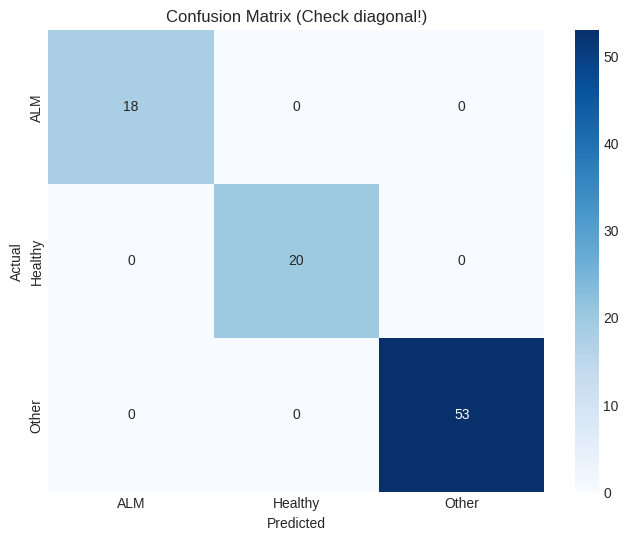

              precision    recall  f1-score   support

         ALM       1.00      1.00      1.00        18
     Healthy       1.00      1.00      1.00        20
       Other       1.00      1.00      1.00        53

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



In [ ]:
# @title 3. Build & Train Model (With Class Weights)
import numpy as np
from sklearn.utils import class_weight

# --- 1. Calculate Class Weights (The Fix) ---
# We need to count how many images are in each class to balance them
print("⚖️ Calculating Class Weights...")

# We have to iterate the dataset once to count labels (since we mapped them)
train_labels = []
for images, labels in train_ds.unbatch():
    train_labels.append(labels.numpy())

train_labels = np.array(train_labels)
class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for Keras
class_weights = dict(enumerate(class_weights_vals))
print(f"✅ Class Weights Computed: {class_weights}")
print("   (This tells the model to pay more attention to rare classes)")

# --- 2. Build Model ---
def build_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = applications.densenet.preprocess_input(x)

    base_model = applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=x)
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs), base_model

model, base_model = build_model(3)

# --- 3. Training with Weights ---
print("\n🚀 Phase 1: Training Head...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
]

# IMPORTANT: Added class_weight parameter here
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks,
    class_weight=class_weights
)

# --- 4. Fine-Tuning ---
print("\n🔓 Phase 2: Fine-Tuning...")
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)

model.save("onycoscan_weighted.keras")

# @title Check Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred = []
y_true = []

print("Running inference on validation set...")
for img, label in val_ds:
    preds = model.predict(img, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(label.numpy())

# Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["ALM", "Healthy", "Other"],
            yticklabels=["ALM", "Healthy", "Other"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Check diagonal!)')
plt.show()

print(classification_report(y_true, y_pred, target_names=["ALM", "Healthy", "Other"]))

In [ ]:
# @title 4. Build Clinical RAG Engine (Updated)
from sentence_transformers import SentenceTransformer
import faiss
import json

# 1. Expanded Knowledge Base to cover "Other" conditions
guidelines_data = [
    # --- MELANOMA (Class 0) ---
    {
        "class_group": "Acral_Melanoma",
        "signal": "Hutchinson sign",
        "description": "Pigment extending onto the periungual skin (cuticle).",
        "risk": "Critical",
        "recommendation": "Urgent dermatology referral for biopsy.",
    },
    {
        "class_group": "Acral_Melanoma",
        "signal": "Longitudinal Melanonychia",
        "description": "Irregular pigmented band >3mm, variegated colors, or widening proximally.",
        "risk": "Critical",
        "recommendation": "Dermoscopic evaluation required.",
    },
    # --- HEALTHY (Class 1) ---
    {
        "class_group": "Healthy_Nail",
        "signal": "Clear nail plate",
        "description": "Smooth texture, uniform color, no pigmentation or dystrophy.",
        "risk": "Low",
        "recommendation": "Routine monitoring.",
    },
    # --- OTHER CONDITIONS (Class 2) ---
    {
        "class_group": "Other_Condition",
        "signal": "Nail Clubbing",
        "description": "Bulbous enlargement of fingertips with convex nail plate.",
        "risk": "Moderate",
        "recommendation": "Screen for cardiac or pulmonary causes.",
    },
    {
        "class_group": "Other_Condition",
        "signal": "Nail Pitting",
        "description": "Small depressions (ice-pick) on nail surface.",
        "risk": "Low",
        "recommendation": "Common in psoriasis or alopecia areata.",
    },
    {
        "class_group": "Other_Condition",
        "signal": "Blue Finger",
        "description": "Cyanotic discoloration.",
        "risk": "High (Acute)",
        "recommendation": "Check oxygen saturation and circulation immediately.",
    }
]

# Save for App
with open("guidelines_3way.json", "w") as f:
    json.dump(guidelines_data, f, indent=2)

# 2. Vector Indexing
print("🧠 Initializing RAG Index...")
encoder = SentenceTransformer("all-MiniLM-L6-v2")

# We embed: "Class Group + Signal + Description" for better retrieval context
corpus = [f"{g['class_group']} {g['signal']}: {g['description']}" for g in guidelines_data]
embeddings = encoder.encode(corpus)

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

def retrieve_guidance(query_text):
    """Retrieves guideline based on query."""
    q_vec = encoder.encode([query_text])
    D, I = index.search(q_vec, k=1)
    return guidelines_data[I[0][0]]

print("✅ RAG Engine Ready with expanded 'Other' class definitions.")

🧠 Initializing RAG Index...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ RAG Engine Ready with expanded 'Other' class definitions.


In [ ]:
# @title 🏥 The OnycoScan Clinical Agent (Interactive)
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPImage
import tensorflow as tf
import numpy as np
from PIL import Image
import io

# --- 1. SETUP & LOAD MODEL ---
# Load your best trained model
try:
    model = tf.keras.models.load_model("onycoscan_weighted.keras")
    print("✅ Model Loaded.")
except:
    print("⚠️ Model not found. Please run the training cell first.")
    # Dummy model for testing flow if file missing
    model = None

CLASSES = ["Acral_Melanoma", "Healthy_Nail", "Other_Condition"]

# --- 2. THE CLINICAL INTERVIEW (Questionnaire) ---
class PatientIntake:
    def __init__(self):
        self.history = {}

        # The specific questions from your guidelines
        self.questions = [
            {"key": "age", "q": "Patient Age:", "type": "text"},
            {"key": "sex", "q": "Biological Sex:", "type": "dropdown", "opts": ["Male", "Female", "Intersex"]},
            {"key": "skin_type", "q": "Skin Type (Fitzpatrick):", "type": "dropdown", "opts": ["I (Pale)", "II", "III", "IV", "V", "VI (Deeply Pigmented)"]},
            {"key": "duration", "q": "Duration of pigmentation (months):", "type": "text"},
            {"key": "evolution", "q": "Has it changed? (Widening/Darkening):", "type": "dropdown", "opts": ["No Change", "Yes - Widening", "Yes - Darkening", "Yes - Both"]},
            {"key": "trauma", "q": "History of Trauma to this nail?", "type": "dropdown", "opts": ["No", "Yes (Recent)", "Yes (Old)"]},
            {"key": "family_hx", "q": "Family history of Melanoma?", "type": "dropdown", "opts": ["No", "Yes (1st Degree)", "Yes (Extended)"]},
            {"key": "pain", "q": "Symptoms (Pain/Bleeding/Ulcer):", "type": "dropdown", "opts": ["None", "Pain", "Bleeding", "Ulceration"]}
        ]

    def render_form(self):
        self.widgets = {}
        ui_elements = []

        print("\n📝 PATIENT INTAKE FORM (Epic Style)")
        print("-" * 40)

        for item in self.questions:
            label = widgets.Label(item['q'])
            if item['type'] == 'text':
                w = widgets.Text(placeholder='Type here...')
            elif item['type'] == 'dropdown':
                w = widgets.Dropdown(options=item['opts'])

            self.widgets[item['key']] = w
            ui_elements.append(widgets.VBox([label, w]))

        return widgets.VBox(ui_elements)

    def get_data(self):
        return {k: v.value for k, v in self.widgets.items()}

# --- 3. THE REASONING ENGINE (The "Brain") ---
def generate_diagnosis(history, visual_class, visual_conf):
    """
    This function acts as the LLM Logic Layer.
    It combines Clinical History (Trauma/Time) + Visuals (CNN)
    to prevent false positives from hematomas (blood).
    """

    # 1. EXTRACT CRITICAL SIGNALS
    is_trauma = "Yes" in history['trauma']
    is_changing = "Yes" in history['evolution']
    is_family_risk = "Yes" in history['family_hx']
    duration = history['duration']

    # 2. VISUAL FINDING
    visual_finding = visual_class # "Acral_Melanoma", "Healthy", or "Other"

    # 3. SYNTHESIS LOGIC (The Guidelines)

    # CASE A: MODEL SAYS MELANOMA
    if visual_finding == "Acral_Melanoma":
        if is_trauma and not is_changing:
            # HISTORY CONTRADICTION: Looks like cancer, but pt reports trauma
            diagnosis = "Suspicious for Subungual Hematoma vs. Melanoma."
            action = "Perform dermoscopy. Look for proximal widening. If pigment moves out with nail growth, it is blood. If it persists, BIOPSY."
            risk_level = "High (Rule out malignancy)"

        elif is_trauma and is_changing:
            # DANGER: Trauma history might be a distraction (Recall bias)
            diagnosis = "High Probability of Acral Lentiginous Melanoma."
            action = "Trauma history noted but lesion is evolving. Immediate referral for matrix biopsy required."
            risk_level = "CRITICAL"

        else:
            # CLASSIC PRESENTATION
            diagnosis = "DIAGNOSE FOR SUBUNGUAL MELANOMA."
            action = f"Visual confidence {visual_conf:.1f}%. Absence of trauma history + visual match requires urgent excision/biopsy."
            risk_level = "CRITICAL"

    # CASE B: MODEL SAYS HEALTHY
    elif visual_finding == "Healthy_Nail":
        if is_changing or "Pain" in history['pain']:
            diagnosis = "Visually Benign, Symptomatically Suspicious."
            action = "Model detects healthy nail, but patient reports symptoms. Monitor for 4 weeks."
            risk_level = "Low-Moderate"
        else:
            diagnosis = "Nail appears healthy."
            action = "Routine follow-up. No intervention needed."
            risk_level = "Low"

    # CASE C: MODEL SAYS OTHER
    else:
        diagnosis = "Dystrophic Nail / Other Condition detected."
        action = "Evaluate for fungal infection (Onychomycosis), Psoriasis, or friction trauma."
        risk_level = "Low"

    return diagnosis, action, risk_level

# --- 4. MAIN APPLICATION LOOP ---
intake = PatientIntake()
form_ui = intake.render_form()

# Image Upload Widget
upload_btn = widgets.FileUpload(accept='image/*', multiple=False)
run_btn = widgets.Button(description="🧠 Run Analysis", button_style='danger')
out = widgets.Output()

def on_run_click(b):
    with out:
        clear_output()

        # 1. Get History
        history = intake.get_data()

        # 2. Get Image
        if not upload_btn.value:
            print("❌ Please upload an image first!")
            return

        # Extract image from widget
        uploaded_file = list(upload_btn.value.values())[0]
        content = uploaded_file['content']
        img = Image.open(io.BytesIO(content)).convert('RGB')

        # Display Image
        display(img.resize((150,150)))

        # 3. Run Vision Model
        img_arr = tf.keras.preprocessing.image.img_to_array(img.resize((224, 224)))
        img_arr = tf.keras.applications.densenet.preprocess_input(img_arr)
        img_arr = np.expand_dims(img_arr, axis=0)

        preds = model.predict(img_arr, verbose=0)
        class_idx = np.argmax(preds[0])
        confidence = np.max(preds[0]) * 100
        visual_label = CLASSES[class_idx]

        print(f"\n👁️ COMPUTER VISION ANALYSIS:")
        print(f"   Detected: {visual_label}")
        print(f"   Confidence: {confidence:.2f}%")

        # 4. Run Reasoning Engine (LLM Simulation)
        diag, action, risk = generate_diagnosis(history, visual_label, confidence)

        print("\n" + "="*50)
        print(f"🤖 AI CLINICAL SYNTHESIS")
        print("="*50)
        print(f"Risk Level:  {risk}")
        print(f"Diagnosis:   {diag}")
        print(f"Plan:        {action}")
        print("="*50)

        # Disclaimer
        print("\n⚠️ RESEARCH USE ONLY. NOT A MEDICAL DEVICE.")

run_btn.on_click(on_run_click)

# Display UI
display(form_ui)
display(widgets.Label("📸 Upload Nail Photo:"))
display(upload_btn)
display(run_btn)
display(out)

✅ Model Loaded.

📝 PATIENT INTAKE FORM (Epic Style)
----------------------------------------


Label(value='📸 Upload Nail Photo:')

FileUpload(value={}, accept='image/*', description='Upload')

Button(button_style='danger', description='🧠 Run Analysis', style=ButtonStyle())

Output()